In [114]:
import torch
import pandas as pd
from torch.utils.data import Dataset
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [115]:
# Import dataframe
# Contains both phage and e.coli proteins!
df = pd.read_parquet("../data/final_df.parquet")
df = df[df["phage_id"] != "NC_000913.3"].copy()
df_final = df[["protein_id", "namespace", "embedding"]]
df_final.reset_index(inplace=True, drop=True)
df_final

,protein_id,namespace,embedding
0,XPK40951.1,biological_process,"[125.5588, -79.63523, 75.97162, 12.756238, 71...."
1,XPK43261.1,biological_process,"[99.659424, -51.160362, 66.22639, -51.286892, ..."
2,XPK41564.1,biological_process,"[111.65291, -51.645664, 76.171875, -51.0761, 9..."
3,XPK40440.1,biological_process,"[132.59705, -90.81759, 72.479294, 24.789663, 7..."
4,QXV76843.1,biological_process,"[127.90173, -77.47774, 69.211945, 22.287302, 7..."
...,...,...,...
3950,YP_006843.1,biological_process,"[56.490303, -98.886856, 116.335396, 55.581356,..."
3951,QXV85222.1,biological_process,"[39.115974, -111.263466, 83.92349, 12.382543, ..."
3952,QXV80335.1,biological_process,"[41.742188, -129.28825, 105.71013, 18.93979, 1..."
3953,QXV77353.1,biological_process,"[45.662178, -141.82974, 106.98464, 54.453396, ..."


In [116]:
# Weights for unbalanced classes
# Max(Number of occurrences in most common class) / (Number of occurrences in rare classes)
set = df_final["namespace"].value_counts()
print(set)
weights = [set.max() / i for i in set]

weights[2] = 3.0  # augment

namespace
molecular_function    1910
biological_process    1855
cellular_component     190
Name: count, dtype: int64


In [117]:
class ProteinDataset(Dataset):
    def __init__(self, df):
        self.df = df
        self.label_to_index = {
            "cellular_component": 0,
            "biological_process": 1,
            "molecular_function": 2,
        }

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        embedding = torch.Tensor(row["embedding"])
        label = self.label_to_index[row["namespace"]]
        return embedding, torch.tensor(label, dtype=torch.long)

In [118]:
class ProteinClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, num_classes=3, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, x):
        return self.net(x)

In [119]:
dataset = ProteinDataset(df_final)

# Split training/validation 80/20
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32)

# Get embedding dimension
sample_emb, _ = dataset[0]
input_dim = sample_emb.shape[0]

# Model, loss, optimizer
model = ProteinClassifier(input_dim=input_dim)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = optim.Adam(model.parameters(), lr=1e-4)
class_weights = torch.FloatTensor(weights).to(device)
criterion = nn.CrossEntropyLoss()
model.to(device)

for epoch in range(10):
    model.train()
    total_loss = 0
    for emb, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}"):
        emb, labels = emb.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(emb)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Train Loss: {total_loss / len(train_loader):.4f}")

    # Validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for emb, labels in val_loader:
            emb, labels = emb.to(device), labels.to(device)
            preds = model(emb).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    print(f"Validation Accuracy: {correct / total:.3f}")

Epoch 1: 100%|██████████| 99/99 [00:30<00:00,  3.28it/s]


Train Loss: 8.8341
Validation Accuracy: 0.704


Epoch 2: 100%|██████████| 99/99 [00:26<00:00,  3.71it/s]


Train Loss: 2.9603
Validation Accuracy: 0.678


Epoch 3: 100%|██████████| 99/99 [00:27<00:00,  3.59it/s]


...

Train Loss: 0.5965
Validation Accuracy: 0.761


Epoch 9: 100%|██████████| 99/99 [00:25<00:00,  3.85it/s]


Train Loss: 0.5483
Validation Accuracy: 0.771


Epoch 10: 100%|██████████| 99/99 [00:26<00:00,  3.76it/s]


Train Loss: 0.5244
Validation Accuracy: 0.796


                    precision    recall  f1-score   support

cellular_component       0.75      0.96      0.84        47
biological_process       0.82      0.78      0.80       374
molecular_function       0.78      0.79      0.79       370

          accuracy                           0.80       791
         macro avg       0.78      0.84      0.81       791
      weighted avg       0.80      0.80      0.80       791



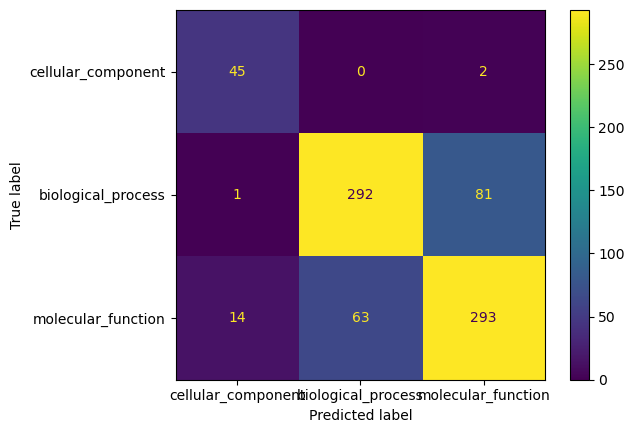

In [120]:
# Collect predictions
label_to_index = {
    "cellular_component": 0,
    "biological_process": 1,
    "molecular_function": 2,
}
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for emb, labels in val_loader:
        emb = emb.to(device)
        preds = model(emb).argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=label_to_index.keys()))

cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_to_index.keys())
disp.plot()
plt.show()

**without class weights**

                    precision    recall  f1-score   support

cellular_component       0.75      0.96      0.84        47
biological_process       0.82      0.78      0.80       374
molecular_function       0.78      0.79      0.79       370

          accuracy                           0.80       791
         macro avg       0.78      0.84      0.81       791
      weighted avg       0.80      0.80      0.80       791

**with weights**
                    precision    recall  f1-score   support

cellular_component       0.88      0.16      0.27        89
biological_process       0.81      0.13      0.22      1182
molecular_function       0.47      0.99      0.64       977

          accuracy                           0.50      2248
         macro avg       0.72      0.43      0.37      2248
      weighted avg       0.67      0.50      0.40      2248